<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [5]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-01-11 22:40:02--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  75.4MB/s    in 2.0s    

2026-01-11 22:40:04 (75.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


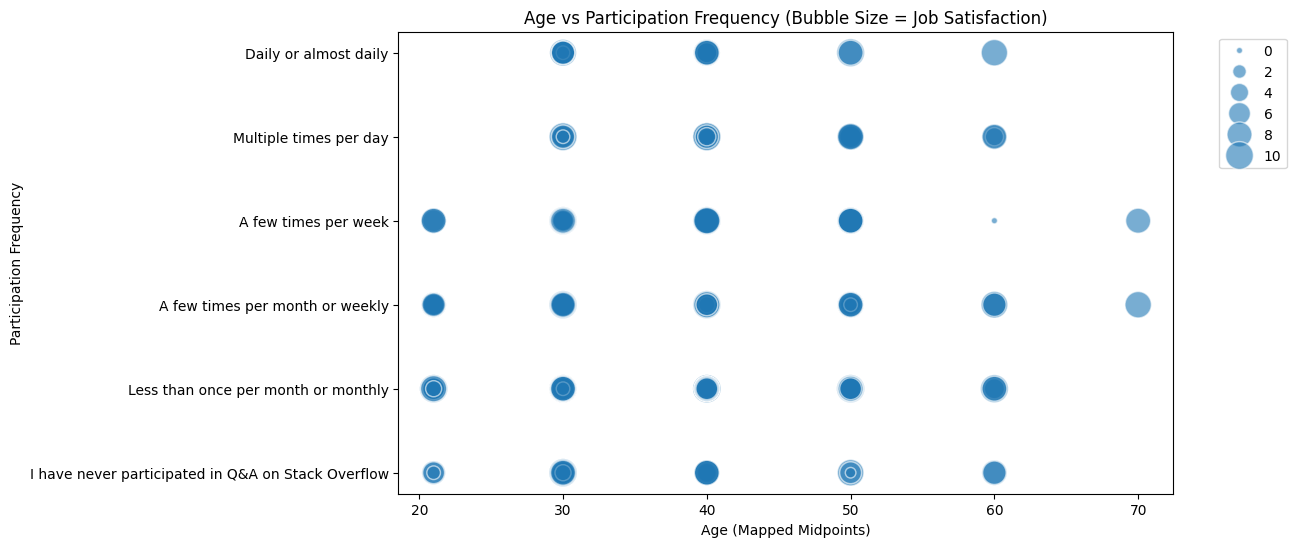

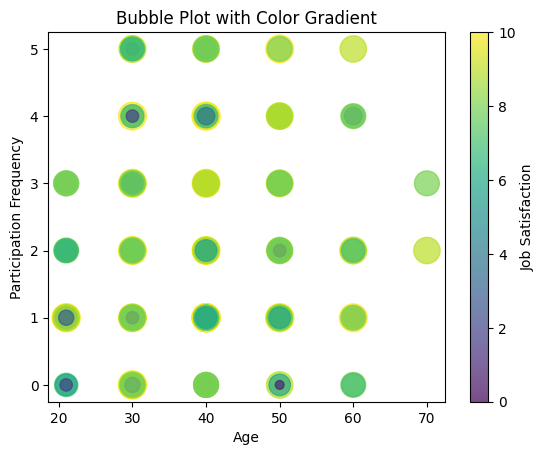

In [11]:
##Write your code here

age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}


partfreq_map = {
    'I have never participated in Q&A on Stack Overflow': 0,
    'Less than once per month or monthly': 1,
    'A few times per month or weekly': 2,
    'A few times per week': 3,
    'Multiple times per day': 4,
    'Daily or almost daily': 5
}

df['Age_mapped'] = df['Age'].map(age_map)
df['PartFreq_mapped'] = df['SOPartFreq'].map(partfreq_map)

clean_df = df[['Age_mapped', 'PartFreq_mapped', 'JobSat']].dropna().head(300)
 
plt.figure(figsize=(10, 6))



sns.scatterplot(
    x='Age_mapped',
    y='PartFreq_mapped',
    size='JobSat',
    data=clean_df,
    alpha=0.6,
    sizes=(20, 400)
)

plt.xlabel('Age (Mapped Midpoints)')
plt.ylabel('Participation Frequency')
plt.yticks(
    list(partfreq_map.values()),
    list(partfreq_map.keys())
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Age vs Participation Frequency (Bubble Size = Job Satisfaction)')
plt.show()

plt.scatter(
    clean_df['Age_mapped'],
    clean_df['PartFreq_mapped'],
    s=clean_df['JobSat'] * 40,     # bubble size
    c=clean_df['JobSat'],          # <-- color by numeric value
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(label='Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Participation Frequency')
plt.title('Bubble Plot with Color Gradient')
plt.show()
##The bubble plot shows that participation frequency varies across all age groups, and job 
##satisfaction does not exhibit a strong relationship with either age or participation frequency

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


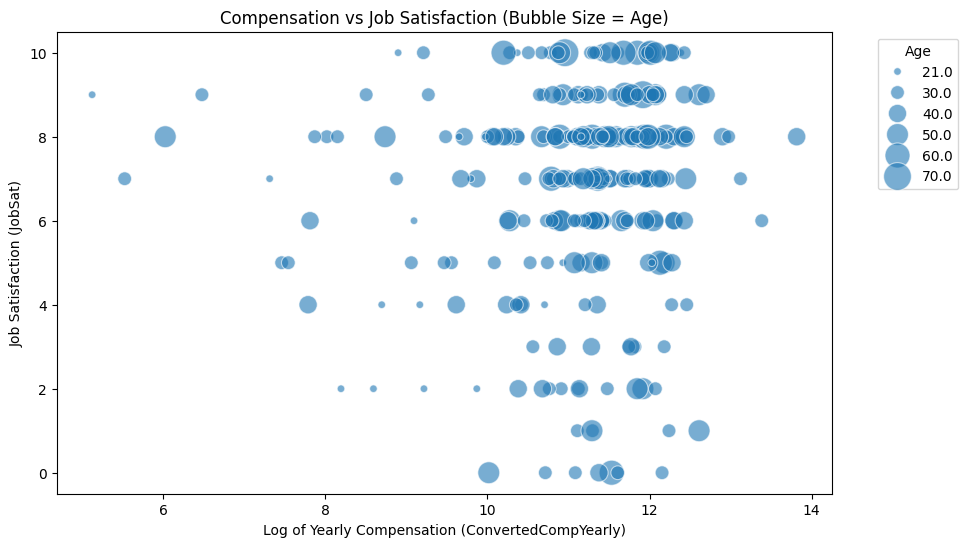

In [14]:
##Write your code here
# Select required columns and drop missing values
clean_df = df[['ConvertedCompYearly', 'JobSat', 'Age_mapped']].dropna().head(300)

# Log-transform compensation (important for skewed salary data)
clean_df['LogComp'] = np.log1p(clean_df['ConvertedCompYearly'])

# Bubble plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clean_df,
    x='LogComp',
    y='JobSat',
    size='Age_mapped',
    alpha=0.6,
    sizes=(30, 400)
)

plt.xlabel('Log of Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSat)')
plt.title('Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.legend(title='Age', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##The bubble plot shows that job satisfaction varies widely across compensation levels, and age does not significantly alter this relationship.

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



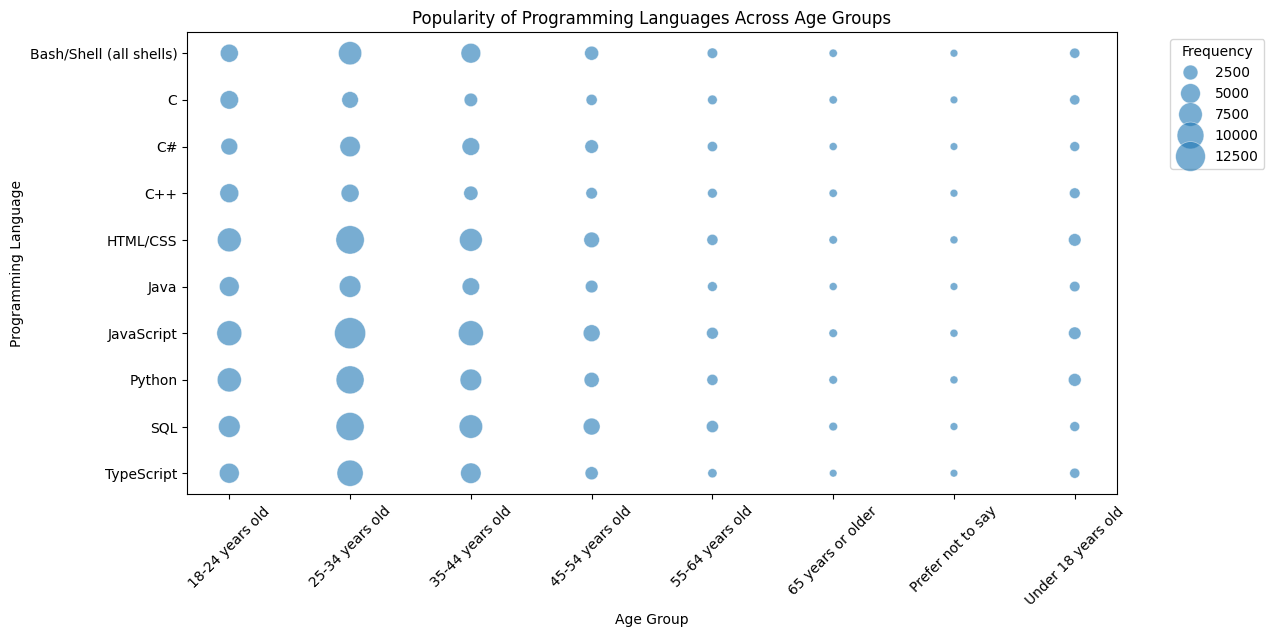

In [15]:
##Write your code here

# Keep required columns
lang_df = df[['Age', 'LanguageHaveWorkedWith']].dropna()

# Split languages into separate rows
lang_df = lang_df.assign(
    LanguageHaveWorkedWith=lang_df['LanguageHaveWorkedWith'].str.split(';')
).explode('LanguageHaveWorkedWith')
lang_counts = (
    lang_df
    .groupby(['Age', 'LanguageHaveWorkedWith'])
    .size()
    .reset_index(name='Frequency')
)
top_languages = (
    lang_counts.groupby('LanguageHaveWorkedWith')['Frequency']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

lang_counts = lang_counts[
    lang_counts['LanguageHaveWorkedWith'].isin(top_languages)
]
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=lang_counts,
    x='Age',
    y='LanguageHaveWorkedWith',
    size='Frequency',
    alpha=0.6,
    sizes=(30, 500)
)

plt.xlabel('Age Group')
plt.ylabel('Programming Language')
plt.title('Popularity of Programming Languages Across Age Groups')
plt.xticks(rotation=45)
plt.legend(title='Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##The bubble plot shows that a small set of core programming languages are widely used across all age groups, while language diversity and usage peak in the 25–44 age range.

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


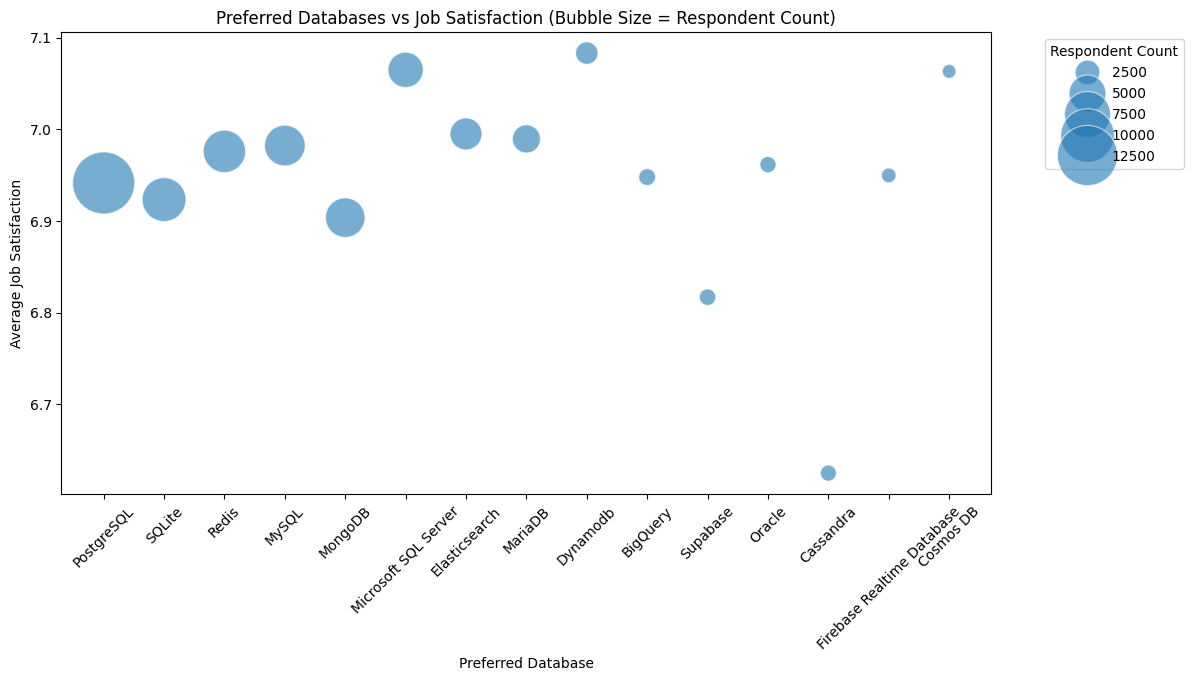

In [19]:
##Write your code here
# Keep required columns and drop missing values
db_df = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

# Split multiple databases into separate rows
db_df = db_df.assign(
    DatabaseWantToWorkWith=db_df['DatabaseWantToWorkWith'].str.split(';')
).explode('DatabaseWantToWorkWith')
db_summary = (
    db_df
    .groupby('DatabaseWantToWorkWith')
    .agg(
        Avg_JobSat=('JobSat', 'mean'),
        Respondent_Count=('JobSat', 'count')
    )
    .reset_index()
)
top_dbs = (
    db_summary
    .sort_values('Respondent_Count', ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=top_dbs,
    x='DatabaseWantToWorkWith',
    y='Avg_JobSat',
    size='Respondent_Count',
    sizes=(100, 2000),
    alpha=0.6
)

plt.xlabel('Preferred Database')
plt.ylabel('Average Job Satisfaction')
plt.title('Preferred Databases vs Job Satisfaction (Bubble Size = Respondent Count)')
plt.xticks(rotation=45)
plt.legend(title='Respondent Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##The bubble plot shows that although some databases are far more popular than others, average job satisfaction remains relatively similar across database preferences.

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


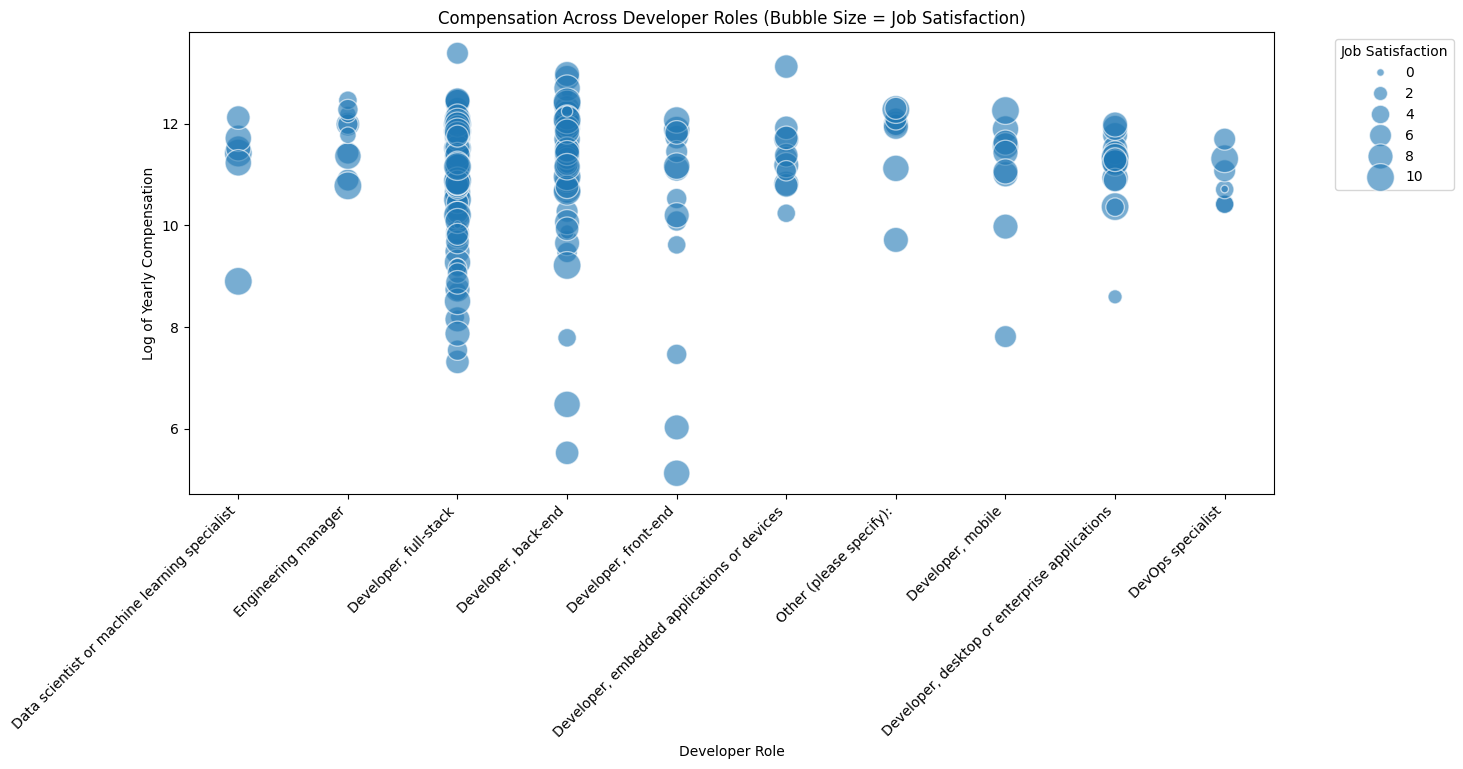

In [21]:
##Write your code here
# Keep relevant columns and drop missing values
dev_df = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna().head(300)

# Split multiple roles into separate rows
dev_df = dev_df.assign(
    DevType=dev_df['DevType'].str.split(';')
).explode('DevType')
top_roles = (
    dev_df['DevType']
    .value_counts()
    .head(10)
    .index
)

dev_df = dev_df[dev_df['DevType'].isin(top_roles)]
dev_df['LogComp'] = np.log1p(dev_df['ConvertedCompYearly'])
plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=dev_df,
    x='DevType',
    y='LogComp',
    size='JobSat',
    alpha=0.6,
    sizes=(30, 400)
)

plt.xlabel('Developer Role')
plt.ylabel('Log of Yearly Compensation')
plt.title('Compensation Across Developer Roles (Bubble Size = Job Satisfaction)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##The bubble plot shows substantial compensation variation across developer roles, with job satisfaction distributed across both
##low and high salary levels, indicating no strong salary–satisfaction relationship.

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


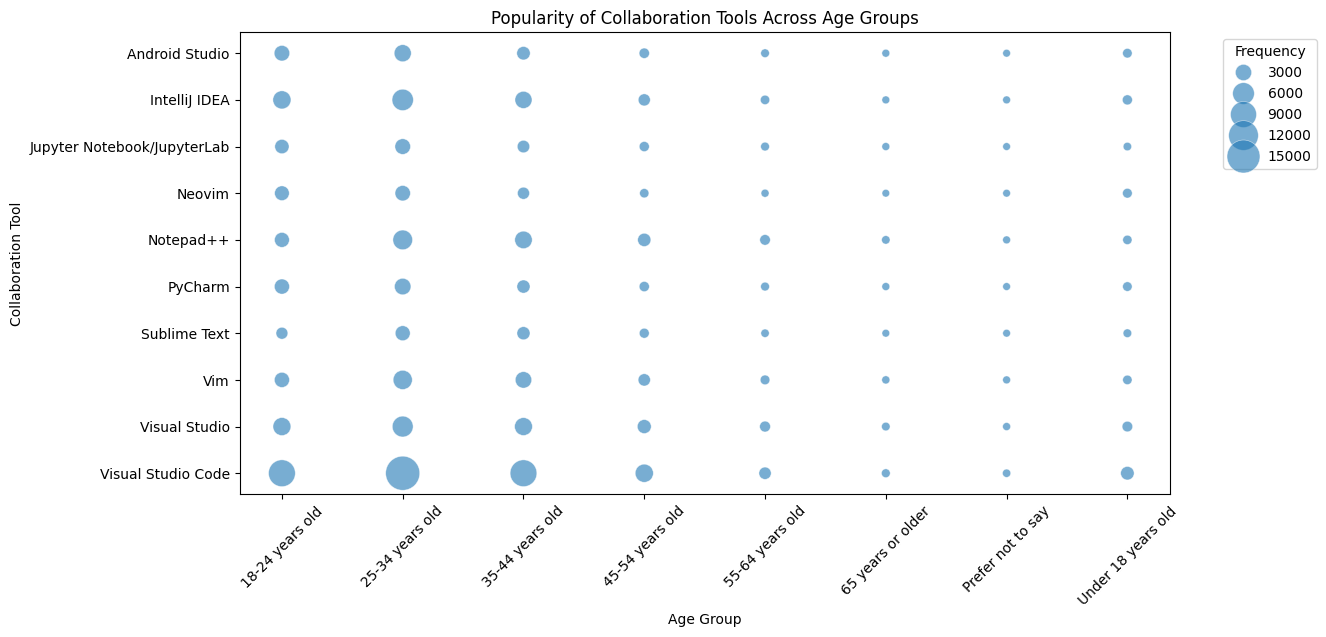

In [22]:
##Write your code here
# Keep required columns and drop missing values
tool_df = df[['Age', 'NEWCollabToolsHaveWorkedWith']].dropna()

# Split multiple tools into separate rows
tool_df = tool_df.assign(
    NEWCollabToolsHaveWorkedWith=tool_df['NEWCollabToolsHaveWorkedWith'].str.split(';')
).explode('NEWCollabToolsHaveWorkedWith')
tool_counts = (
    tool_df
    .groupby(['Age', 'NEWCollabToolsHaveWorkedWith'])
    .size()
    .reset_index(name='Frequency')
)
top_tools = (
    tool_counts.groupby('NEWCollabToolsHaveWorkedWith')['Frequency']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

tool_counts = tool_counts[
    tool_counts['NEWCollabToolsHaveWorkedWith'].isin(top_tools)
]
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=tool_counts,
    x='Age',
    y='NEWCollabToolsHaveWorkedWith',
    size='Frequency',
    alpha=0.6,
    sizes=(30, 600)
)

plt.xlabel('Age Group')
plt.ylabel('Collaboration Tool')
plt.title('Popularity of Collaboration Tools Across Age Groups')
plt.xticks(rotation=45)
plt.legend(title='Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##The bubble plot shows that core collaboration tools—especially Visual Studio Code—are popular across all age groups,
##with usage frequency peaking among mid-career respondents.

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



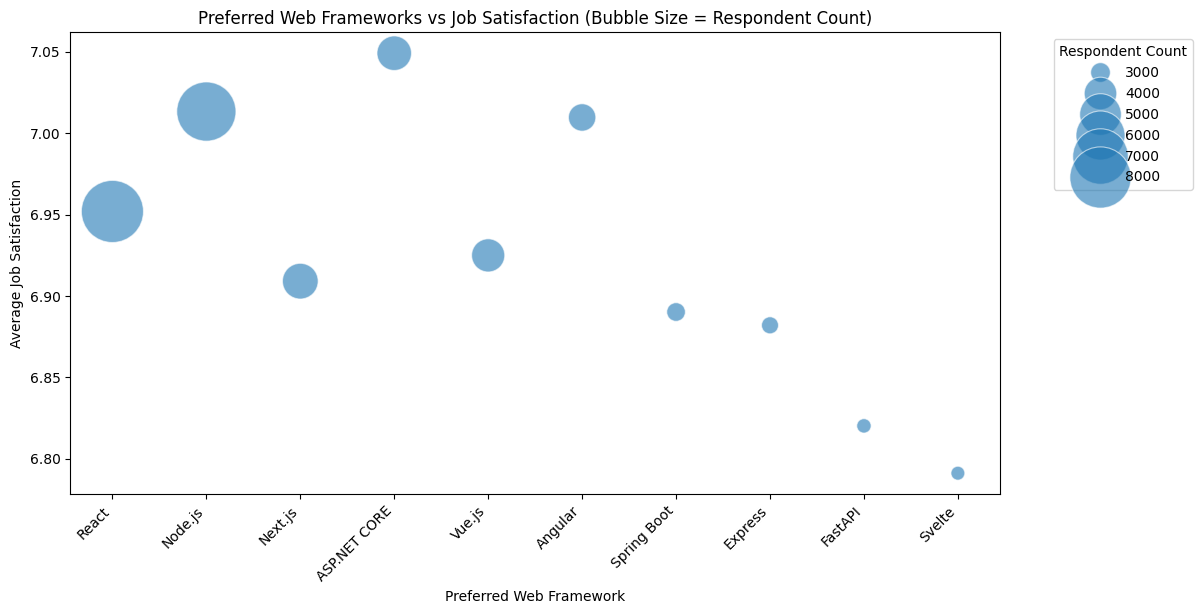

In [23]:
##Write your code here
# Keep required columns
wf_df = df[['WebframeWantToWorkWith', 'JobSat']].dropna()

# Split multiple frameworks into separate rows
wf_df = wf_df.assign(
    WebframeWantToWorkWith=wf_df['WebframeWantToWorkWith'].str.split(';')
).explode('WebframeWantToWorkWith')
wf_summary = (
    wf_df
    .groupby('WebframeWantToWorkWith')
    .agg(
        Avg_JobSat=('JobSat', 'mean'),
        Respondent_Count=('JobSat', 'count')
    )
    .reset_index()
)
top_frameworks = (
    wf_summary
    .sort_values('Respondent_Count', ascending=False)
    .head(10)
)
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=top_frameworks,
    x='WebframeWantToWorkWith',
    y='Avg_JobSat',
    size='Respondent_Count',
    sizes=(100, 2000),
    alpha=0.6
)

plt.xlabel('Preferred Web Framework')
plt.ylabel('Average Job Satisfaction')
plt.title('Preferred Web Frameworks vs Job Satisfaction (Bubble Size = Respondent Count)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Respondent Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##The bubble plot shows that although some web frameworks are more popular than others, average job satisfaction remains relatively similar across framework preferences.

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



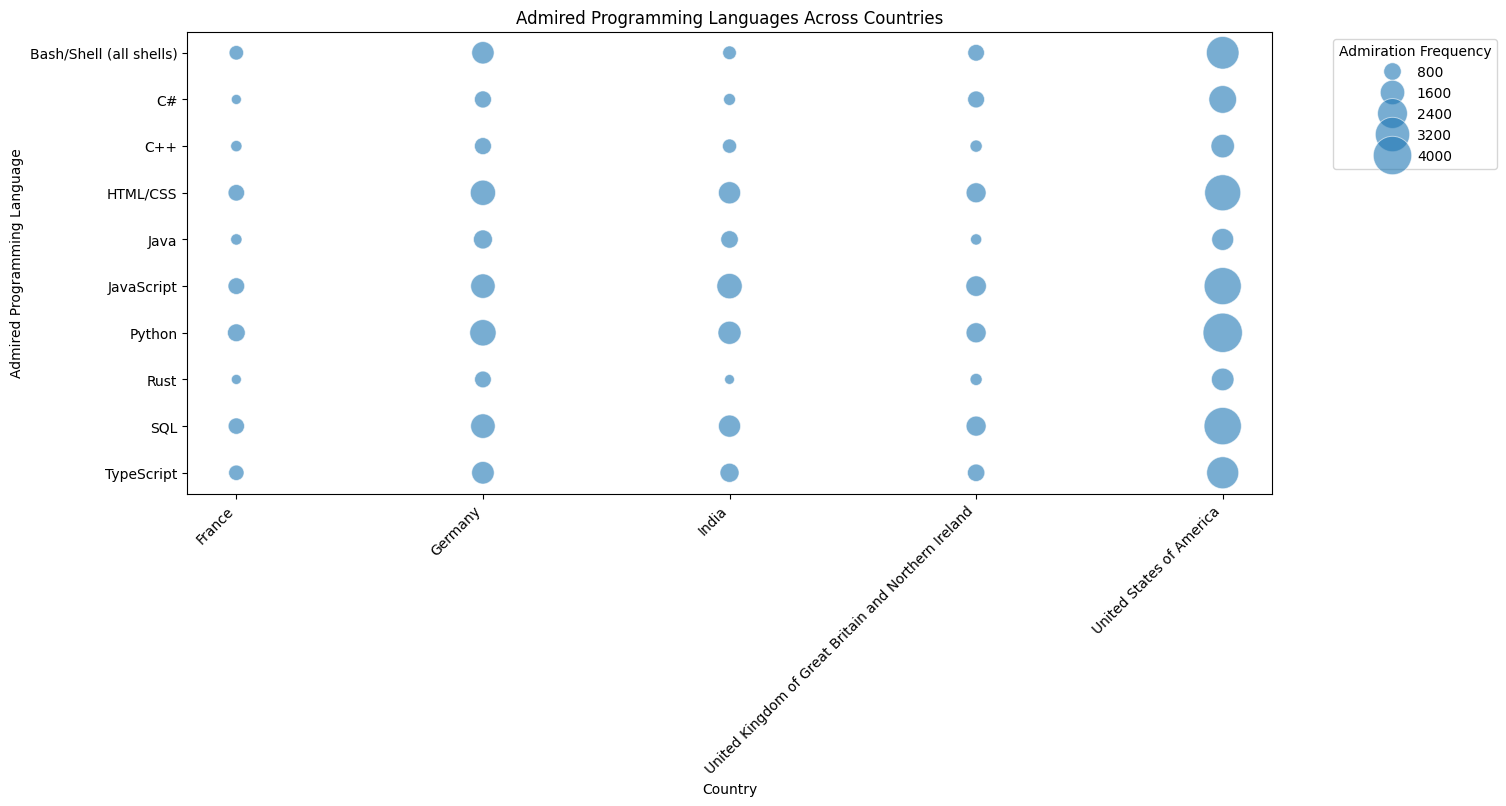

In [24]:
##Write your code here
# Keep required columns
adm_df = df[['Country', 'LanguageAdmired']].dropna()

# Split multiple admired languages into separate rows
adm_df = adm_df.assign(
    LanguageAdmired=adm_df['LanguageAdmired'].str.split(';')
).explode('LanguageAdmired')
##Aggregate Frequency by Country and Language
adm_counts = (
    adm_df
    .groupby(['Country', 'LanguageAdmired'])
    .size()
    .reset_index(name='Frequency')
)
##Limit to Top Countries & Languages
top_countries = (
    adm_counts.groupby('Country')['Frequency']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_languages = (
    adm_counts.groupby('LanguageAdmired')['Frequency']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

adm_counts = adm_counts[
    (adm_counts['Country'].isin(top_countries)) &
    (adm_counts['LanguageAdmired'].isin(top_languages))
]
plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=adm_counts,
    x='Country',
    y='LanguageAdmired',
    size='Frequency',
    sizes=(50, 800),
    alpha=0.6
)

plt.xlabel('Country')
plt.ylabel('Admired Programming Language')
plt.title('Admired Programming Languages Across Countries')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Admiration Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##The bubble plot shows that a small group of core programming languages is admired across all countries, while admiration intensity varies by region.

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
